In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import os
%matplotlib inline

path = '../Datasets'

In [2]:
def load_data(filename):
    """ Load dataset from filename
    Args:
        filename (string): Path to data
        
    Returns:
        df (DataFrame): Dataset from file
    """
    
    df = pd.read_csv(filename)
    df.drop(df.columns[0], axis=1, inplace=True)
    
    return df

filename = os.path.join(path,'autodf.csv')
df = load_data(filename)
df.head(3)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0


In [3]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [4]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

# Correlation

In [5]:
df.corr()

ValueError: could not convert string to float: 'alfa-romero'

/var/folders/s5/fm0sc7qd6n9dm_v2ysffvs5s4nth35/T/ipykernel_37175/277651017.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  ax = sns.heatmap(df.corr(),vmin=-1,vmax=1,cmap='seismic')


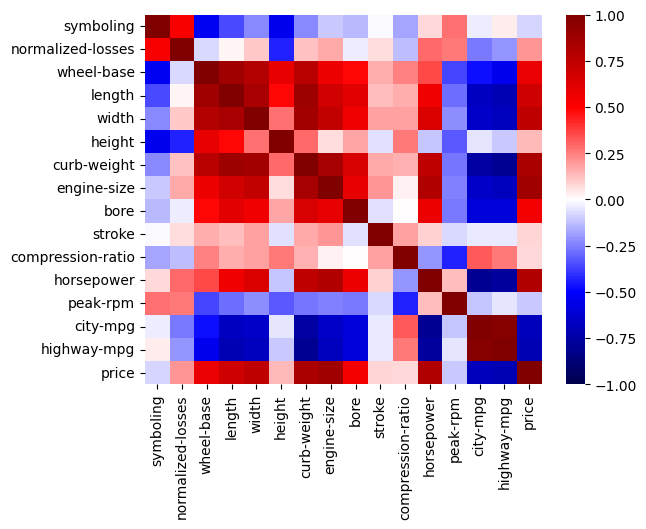

In [6]:
ax = sns.heatmap(df.corr(),vmin=-1,vmax=1,cmap='seismic')

# Histograms

<AxesSubplot: xlabel='horsepower', ylabel='Count'>

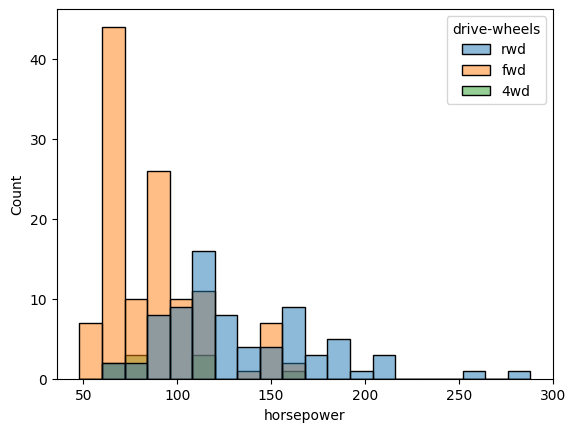

In [7]:
sns.histplot(df[['horsepower','drive-wheels']],x='horsepower',bins=20,hue='drive-wheels')
#sns.histplot(df[['horsepower','drive-wheels']], x='horsepower', bins=20)

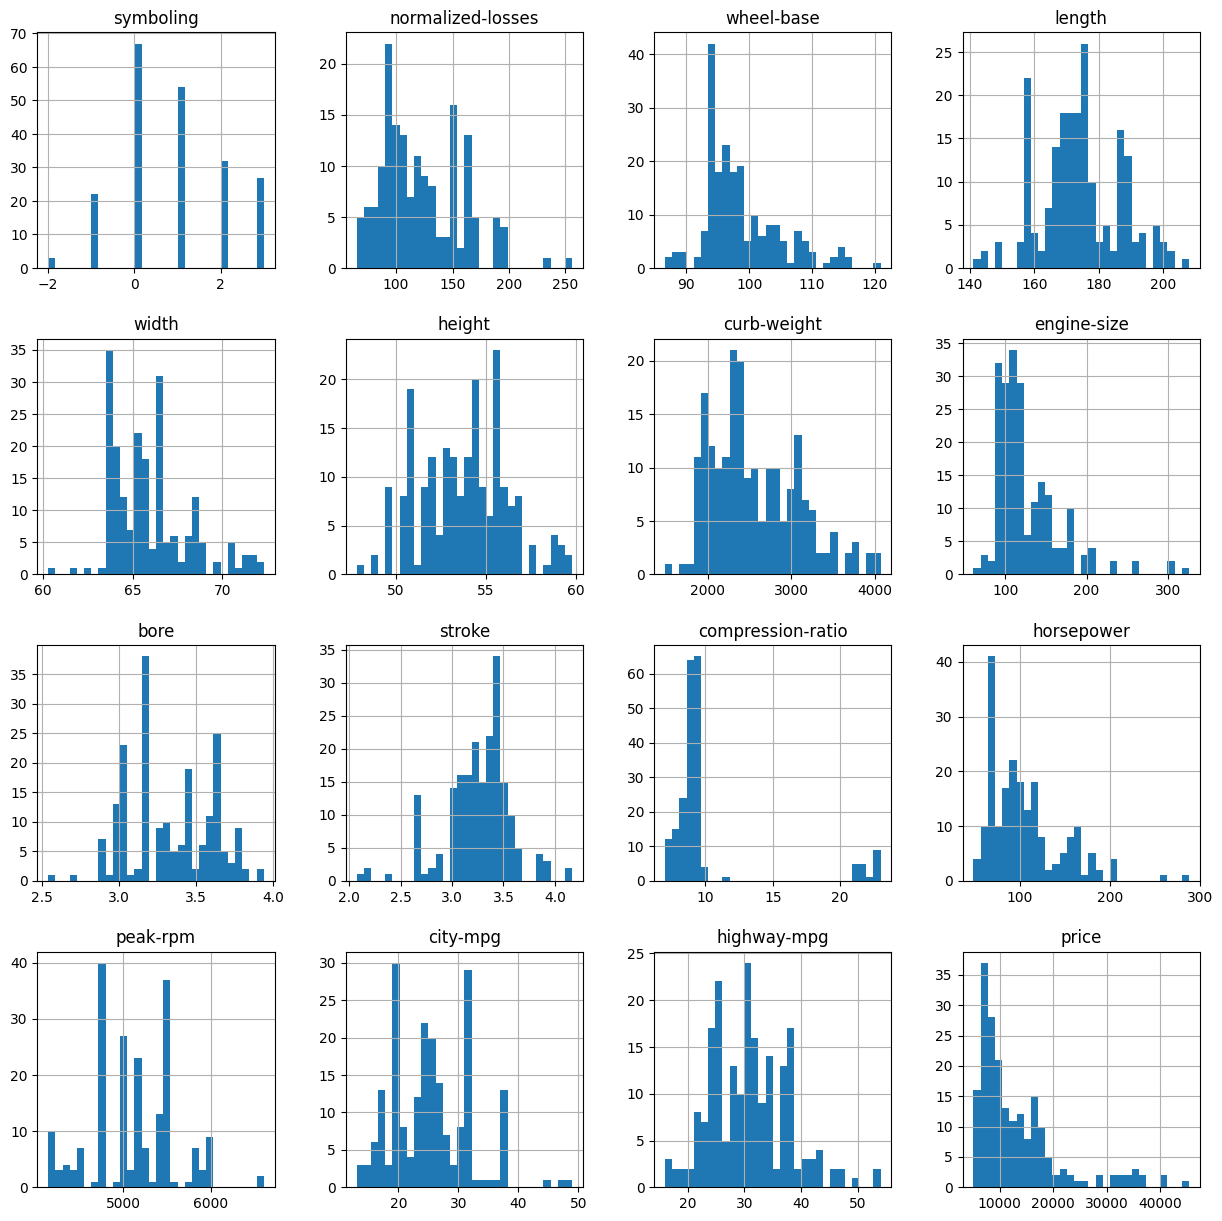

In [8]:
df.hist(figsize=(15,15),bins=30);

In [9]:
df_r = df[['drive-wheels','horsepower','engine-size','length', 'width', 'height','curb-weight','city-mpg']]
df_r

,drive-wheels,horsepower,engine-size,length,width,height,curb-weight,city-mpg
0,rwd,111.0,130,168.8,64.1,48.8,2548,21
1,rwd,111.0,130,168.8,64.1,48.8,2548,21
2,rwd,154.0,152,171.2,65.5,52.4,2823,19
3,fwd,102.0,109,176.6,66.2,54.3,2337,24
4,4wd,115.0,136,176.6,66.4,54.3,2824,18
...,...,...,...,...,...,...,...,...
200,rwd,114.0,141,188.8,68.9,55.5,2952,23
201,rwd,160.0,141,188.8,68.8,55.5,3049,19
202,rwd,134.0,173,188.8,68.9,55.5,3012,18
203,rwd,106.0,145,188.8,68.9,55.5,3217,26


In [10]:
y = df_r['city-mpg'].values
y

array([21, 21, 19, 24, 18, 19, 19, 19, 17, 16, 23, 23, 21, 21, 20, 16, 16,
       15, 47, 38, 38, 37, 31, 24, 31, 31, 31, 24, 24, 19, 49, 31, 38, 30,
       30, 30, 30, 27, 27, 27, 27, 24, 25, 24, 38, 38, 24, 15, 15, 13, 30,
       31, 31, 31, 31, 17, 17, 17, 16, 26, 26, 26, 26, 36, 26, 19, 31, 22,
       22, 22, 22, 16, 16, 14, 14, 19, 37, 31, 31, 24, 23, 25, 19, 19, 19,
       25, 25, 23, 23, 31, 45, 31, 31, 31, 31, 31, 31, 31, 31, 27, 27, 17,
       17, 19, 19, 17, 19, 19, 28, 19, 25, 19, 28, 19, 25, 19, 28, 18, 37,
       24, 31, 31, 31, 24, 19, 19, 17, 17, 17, 17, 23, 23, 21, 21, 21, 21,
       19, 19, 31, 26, 26, 32, 28, 26, 24, 24, 28, 25, 23, 23, 35, 31, 31,
       31, 27, 27, 30, 30, 34, 38, 38, 28, 28, 29, 29, 26, 26, 24, 24, 24,
       24, 24, 24, 29, 30, 27, 27, 27, 20, 19, 20, 19, 37, 27, 37, 27, 27,
       37, 26, 24, 24, 19, 33, 25, 23, 23, 24, 24, 17, 17, 23, 19, 18, 26,
       19])

In [11]:
# drop target
df_r = df_r.drop('city-mpg', axis=1)

# Ecoding categorical values
Involves a two step process:
- `Label Encoding`
- `One-hot Encoding`

In [12]:
from sklearn.preprocessing import LabelEncoder

dw_cat = df_r['drive-wheels']
dw_cat.values

array(['rwd', 'rwd', 'rwd', 'fwd', '4wd', 'fwd', 'fwd', 'fwd', 'fwd',
       '4wd', 'rwd', 'rwd', 'rwd', 'rwd', 'rwd', 'rwd', 'rwd', 'rwd',
       'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd',
       'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd',
       'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'rwd', 'fwd',
       'fwd', 'rwd', 'rwd', 'rwd', 'rwd', 'fwd', 'fwd', 'fwd', 'fwd',
       'fwd', 'rwd', 'rwd', 'rwd', 'rwd', 'fwd', 'fwd', 'fwd', 'fwd',
       'fwd', 'fwd', 'rwd', 'rwd', 'rwd', 'rwd', 'rwd', 'rwd', 'rwd',
       'rwd', 'rwd', 'rwd', 'rwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd',
       'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd',
       'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd',
       'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'rwd', 'rwd', 'rwd', 'rwd',
       'rwd', 'rwd', 'rwd', 'rwd', 'rwd', 'rwd', 'rwd', 'rwd', 'rwd',
       'rwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'fwd', 'rwd', 'rwd',
       'rwd', 'rwd',

In [13]:
# create new label encoder instance and enconde cat data
encoder = LabelEncoder()

dw_cat_encoded = encoder.fit_transform(dw_cat)
dw_cat_encoded

array([2, 2, 2, 1, 0, 1, 1, 1, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2])

In [14]:
print(encoder.classes_)

['4wd' 'fwd' 'rwd']


In [15]:
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder()

dw_onehot_encoded = onehot_encoder.fit_transform(dw_cat_encoded.reshape(-1,1))
# sparse matrix
dw_onehot_encoded

<205x3 sparse matrix of type '<class 'numpy.float64'>'
	with 205 stored elements in Compressed Sparse Row format>

In [16]:
# dense matrix
dw_onehot_encoded.toarray()[0:15,:]

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]])

# Better option `LabelBinarizer`
perform `label encoding` and `one-hot encoding` in a single step

In [17]:

from sklearn.preprocessing import LabelBinarizer

lb_encoder = LabelBinarizer()
dw_lb_encoded = lb_encoder.fit_transform(dw_cat)

print(lb_encoder.classes_)
print()
dw_lb_encoded[0:10,:]

['4wd' 'fwd' 'rwd']



array([[0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0]])

In [18]:
df_r_encoded = pd.concat([df_r, pd.DataFrame(data=dw_lb_encoded, columns=lb_encoder.classes_)],axis=1)
df_r_encoded.head()

,drive-wheels,horsepower,engine-size,length,width,height,curb-weight,4wd,fwd,rwd
0,rwd,111.0,130,168.8,64.1,48.8,2548,0,0,1
1,rwd,111.0,130,168.8,64.1,48.8,2548,0,0,1
2,rwd,154.0,152,171.2,65.5,52.4,2823,0,0,1
3,fwd,102.0,109,176.6,66.2,54.3,2337,0,1,0
4,4wd,115.0,136,176.6,66.4,54.3,2824,1,0,0


In [19]:
df_r_encoded.drop('drive-wheels', axis=1, inplace=True)
df_r_encoded.head()

,horsepower,engine-size,length,width,height,curb-weight,4wd,fwd,rwd
0,111.0,130,168.8,64.1,48.8,2548,0,0,1
1,111.0,130,168.8,64.1,48.8,2548,0,0,1
2,154.0,152,171.2,65.5,52.4,2823,0,0,1
3,102.0,109,176.6,66.2,54.3,2337,0,1,0
4,115.0,136,176.6,66.4,54.3,2824,1,0,0


# Imputation

In [20]:
df_r_encoded.loc[0:5,'horsepower'] = np.nan
df_r_encoded

,horsepower,engine-size,length,width,height,curb-weight,4wd,fwd,rwd
0,NaN,130,168.8,64.1,48.8,2548,0,0,1
1,NaN,130,168.8,64.1,48.8,2548,0,0,1
2,NaN,152,171.2,65.5,52.4,2823,0,0,1
3,NaN,109,176.6,66.2,54.3,2337,0,1,0
4,NaN,136,176.6,66.4,54.3,2824,1,0,0
...,...,...,...,...,...,...,...,...,...
200,114.0,141,188.8,68.9,55.5,2952,0,0,1
201,160.0,141,188.8,68.8,55.5,3049,0,0,1
202,134.0,173,188.8,68.9,55.5,3012,0,0,1
203,106.0,145,188.8,68.9,55.5,3217,0,0,1


In [21]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

imputer.fit(df_r_encoded)

X = imputer.transform(df_r_encoded)

df_r_inputed = pd.DataFrame(X, columns=df_r_encoded.columns,index=df_r_encoded.index)
df_r_inputed

,horsepower,engine-size,length,width,height,curb-weight,4wd,fwd,rwd
0,95.0,130.0,168.8,64.1,48.8,2548.0,0.0,0.0,1.0
1,95.0,130.0,168.8,64.1,48.8,2548.0,0.0,0.0,1.0
2,95.0,152.0,171.2,65.5,52.4,2823.0,0.0,0.0,1.0
3,95.0,109.0,176.6,66.2,54.3,2337.0,0.0,1.0,0.0
4,95.0,136.0,176.6,66.4,54.3,2824.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
200,114.0,141.0,188.8,68.9,55.5,2952.0,0.0,0.0,1.0
201,160.0,141.0,188.8,68.8,55.5,3049.0,0.0,0.0,1.0
202,134.0,173.0,188.8,68.9,55.5,3012.0,0.0,0.0,1.0
203,106.0,145.0,188.8,68.9,55.5,3217.0,0.0,0.0,1.0


# Custom transformers

In [22]:
# class

def func(x):
    return x+1

# dunder (double underscore) init  __init__
class Calculator():
    
    #constuctor 
    def __init__(self, a=0, b=0, allow_negatives=False):
        self.x = a
        self.y = b
        self.allow_negatives = allow_negatives
        print("I'm ready!")
    
    def sum(self):
        if self.allow_negatives:
            return self.x+self.y

    def __repr__(self):
        return f"{self.x}, {self.y} Negatives: {self.allow_negatives}"


calc1 = Calculator(1,3,True)

print(calc1)
print(calc1.sum())

I'm ready!
1, 3 Negatives: True
4


In [23]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

horsepower_idx, engine_size_idx, length_idx, width_idx, height_idx, curb_weight_idx = 0,1,2,3,4,5


class CombineAttributes(BaseEstimator, TransformerMixin):
    """
    """
    def __init__(self, add_volume=False):
        self.add_volume = add_volume

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        hp_to_weight_ratio = X[:,horsepower_idx]/X[:,curb_weight_idx]
        
        if self.add_volume:
            volume = X[:,length_idx]*X[:,width_idx]*X[:,height_idx]
            return np.c_[X, hp_to_weight_ratio, volume]
        
        else:
            return np.c_[X, hp_to_weight_ratio]


combine_attributes = CombineAttributes(add_volume=False)

df_r_combined = combine_attributes.transform(df_r_inputed.values)

In [24]:
print(df_r_combined[0:5,:])

[[9.50000000e+01 1.30000000e+02 1.68800000e+02 6.41000000e+01
  4.88000000e+01 2.54800000e+03 0.00000000e+00 0.00000000e+00
  1.00000000e+00 3.72841444e-02]
 [9.50000000e+01 1.30000000e+02 1.68800000e+02 6.41000000e+01
  4.88000000e+01 2.54800000e+03 0.00000000e+00 0.00000000e+00
  1.00000000e+00 3.72841444e-02]
 [9.50000000e+01 1.52000000e+02 1.71200000e+02 6.55000000e+01
  5.24000000e+01 2.82300000e+03 0.00000000e+00 0.00000000e+00
  1.00000000e+00 3.36521431e-02]
 [9.50000000e+01 1.09000000e+02 1.76600000e+02 6.62000000e+01
  5.43000000e+01 2.33700000e+03 0.00000000e+00 1.00000000e+00
  0.00000000e+00 4.06504065e-02]
 [9.50000000e+01 1.36000000e+02 1.76600000e+02 6.64000000e+01
  5.43000000e+01 2.82400000e+03 1.00000000e+00 0.00000000e+00
  0.00000000e+00 3.36402266e-02]]


# Feature Scaling

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df_r_combined)
print(scaler.transform(df_r_combined))

[[0.19583333 0.26037736 0.41343284 ... 0.         1.         0.26435413]
 [0.19583333 0.26037736 0.41343284 ... 0.         1.         0.26435413]
 [0.19583333 0.34339623 0.44925373 ... 0.         1.         0.20901003]
 ...
 [0.35833333 0.42264151 0.7119403  ... 0.         1.         0.37413667]
 [0.24166667 0.31698113 0.7119403  ... 0.         1.         0.19831013]
 [0.275      0.30188679 0.7119403  ... 0.         1.         0.26353775]]


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df_r_combined)
df_x = scaler.transform(df_r_combined)

print(df_x)

[[-0.216776    0.07444893 -0.42652147 ... -1.18817705  1.30283093
  -0.26921018]
 [-0.216776    0.07444893 -0.42652147 ... -1.18817705  1.30283093
  -0.26921018]
 [-0.216776    0.60404617 -0.23151305 ... -1.18817705  1.30283093
  -0.65166129]
 ...
 [ 0.7758495   1.10957081  1.19854871 ... -1.18817705  1.30283093
   0.48943349]
 [ 0.06319529  0.43553795  1.19854871 ... -1.18817705  1.30283093
  -0.72560213]
 [ 0.26681078  0.33924755  1.19854871 ... -1.18817705  1.30283093
  -0.27485177]]


# Split Train and Test data 

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_x, y, test_size=0.3, random_state=42)

# Testing some models

In [28]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [29]:
lin_reg.predict(X_test)

array([17.03368629, 14.58110505, 25.59410186, 22.76460213, 19.13231176,
       30.90632978, 32.95672872, 30.59952637, 25.73419695, 33.74660485,
       23.59419334, 29.9507247 , 22.7878668 , 26.17289393, 15.06038473,
       33.73353374, 38.22852258, 19.80093795, 26.49237686, 25.73183531,
       27.48159544, 19.76437961, 31.35994154, 35.41064184, 31.54855709,
       16.06203244, 22.20199415, 21.98703182, 30.28090782, 21.89705559,
       19.75501293, 31.51191344, 28.7467275 , 20.30294582, 25.10538585,
       19.92408094, 19.85872257, 24.0209161 , 31.45471181, 19.96465987,
       27.58487707, 28.20784067, 23.42117379, 32.89417924, 31.1864045 ,
       27.87266287, 31.51191344, 31.46001091, 22.71955714, 19.74881899,
       31.33134438, 17.73671522, 34.37297364, 26.37111784, 30.26638523,
       25.33003596, 22.21079156, 24.0209161 , 14.34038116, 31.54671661,
       24.01069319, 19.37040862])

In [30]:
from sklearn.metrics import mean_squared_error

y_predicted = lin_reg.predict(X_test)
lin_mse = mean_squared_error(y_test, y_predicted)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

3.8215907872276014

In [31]:
from sklearn.ensemble import RandomForestRegressor

# use a Random Forest
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(X_train, y_train)
y_predicted = forest_reg.predict(X_test)
forest_mse = mean_squared_error(y_test, y_predicted)
forest_mse = np.sqrt(forest_mse)
forest_mse

3.283898393874317

# Cross validation

In [32]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(forest_reg, df_x, y,scoring="neg_mean_squared_error", cv=10)
rmse_scores = np.sqrt(-scores)
rmse_scores

array([2.79885181, 2.74222277, 3.4225567 , 1.56488399, 2.67462952,
       3.06707215, 2.06911092, 4.54908617, 2.19339691, 2.63918169])

In [33]:
rmse_scores.mean()

2.7720992615113618

# Grid Search
Find find parameters that minimize (localy) the error

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]}, # 12
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]}, # 6
  ]

forest_reg = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(df_x, y)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [35]:
grid_search.best_estimator_

RandomForestRegressor(bootstrap=False, max_features=4, n_estimators=3,
                      random_state=42)

In [36]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

3.562082762140156 {'max_features': 2, 'n_estimators': 3}
3.3321271313550143 {'max_features': 2, 'n_estimators': 10}
3.099538478141006 {'max_features': 2, 'n_estimators': 30}
3.8102841866002364 {'max_features': 4, 'n_estimators': 3}
3.540106102860788 {'max_features': 4, 'n_estimators': 10}
3.2620872580500957 {'max_features': 4, 'n_estimators': 30}
3.702266207034642 {'max_features': 6, 'n_estimators': 3}
3.4046381563405173 {'max_features': 6, 'n_estimators': 10}
3.150510562141956 {'max_features': 6, 'n_estimators': 30}
3.7753271184029216 {'max_features': 8, 'n_estimators': 3}
3.4623758936990496 {'max_features': 8, 'n_estimators': 10}
3.169743614229044 {'max_features': 8, 'n_estimators': 30}
3.613359733500892 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
3.3585202897385282 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
3.9943048888029873 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
3.274074063855269 {'bootstrap': False, 'max_features': 3, 'n_estimat

# Randomized Grid Search

In [37]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
        'n_estimators': randint(low=1, high=200),
        'max_features': randint(low=1, high=9),
    }

forest_reg = RandomForestRegressor(random_state=42)
rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42)
rnd_search.fit(df_x, y)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   param_distributions={'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x169765dc0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x169791c40>},
                   random_state=42, scoring='neg_mean_squared_error')

In [38]:
rnd_search.best_estimator_

RandomForestRegressor(max_features=5, random_state=42)

In [39]:
cvres = rnd_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

3.1231007749939548 {'max_features': 7, 'n_estimators': 180}
3.3220304301528887 {'max_features': 5, 'n_estimators': 15}
3.1340460758867907 {'max_features': 3, 'n_estimators': 72}
3.2563671128976868 {'max_features': 5, 'n_estimators': 21}
3.107337512646249 {'max_features': 7, 'n_estimators': 122}
3.1094569694701435 {'max_features': 3, 'n_estimators': 75}
3.097786446118078 {'max_features': 3, 'n_estimators': 88}
3.0591483686580836 {'max_features': 5, 'n_estimators': 100}
3.1170482203465633 {'max_features': 8, 'n_estimators': 152}
3.109208080144662 {'max_features': 3, 'n_estimators': 150}
